# Custom energies and concentrations

`defermi` offers the possibility to customize the core functions `DefectEntry.formation_energy` and `DefectEntry.defect_concentration`. This is especially useful whenever we want to simulate conditions that deviate from the standard ideal solution model, like temperature-dependent formation energies, or anisotropic systems like interfaces and grain boundaries. 
In this example, we implement temperature-dependent formation energies for $V_O$.

## Temperature-dependent formation energies

We start from our usual example with Sr and O vacancies.

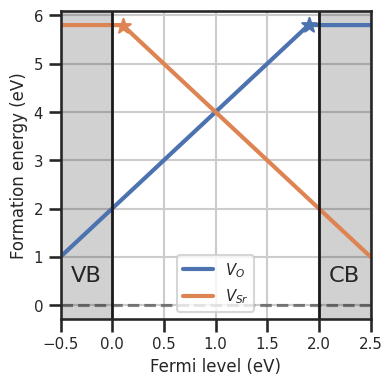

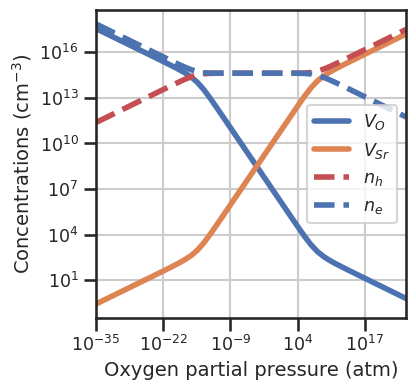

In [39]:
import pandas as pd
from defermi import DefectsAnalysis
import matplotlib.pyplot as plt

import seaborn as sns 
sns.set_theme(context='talk',style='ticks')

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4}
chempots = {'Sr':-2,'O':-5}

da.plot_formation_energies(chempots,figsize=(4,4));
plt.show()

precursors = {'SrO':-10}
da.plot_brouwer_diagram(bulk_dos=bulk_dos,temperature=1000,precursors=precursors,
                        oxygen_ref=-5,pressure_range=(1e-35,1e25),
                        figsize=(4,4),fontsize=14);

Let's assume we were able to calculate the dependency of the formation energies on temperature. We can now define a function to compute the formation energy for this specific case. The function inputs need to be the same as the inputs of the default `formation_energy` function, plus the custom `**kwargs`:
- `entry` : `DefectEntry` object
- `vbm`
- `chemical_potentials`
- `fermi_level`
- `temperature`
- `**kwargs`

In this example, we compute the T-dependent formation energy as:
$$ \Delta E_f (T) = \Delta E_f (0 \mathrm{K}) + E_{shift} (T) $$
with:
$$ \Delta E_f (0 \mathrm{K}) = E_D - E_B + q (\epsilon_{VBM} + \mu_e) - \sum_i \Delta n_i \mu_i $$

For the formation energy at $0 K$ use use the `_default_formation_energy_function`, but it could be programmed explicitely if needed.

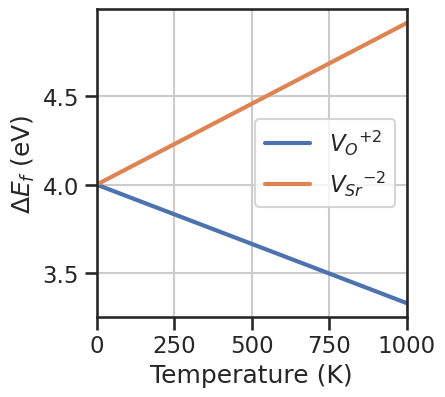

In [26]:
# T-dependent formation energy of VO (made-up for example)
def formation_energy_Vac_O(
                entry,
                vbm=None,
                chemical_potentials=None,
                fermi_level=0,
                temperature=0,
                **kwargs):
        
        formation_energy = entry._default_formation_energy(vbm=vbm,chemical_potentials=chemical_potentials,fermi_level=fermi_level)
        return formation_energy - 1/1500 *temperature       

# T-dependent formation energy of VSr (made-up for example)
def formation_energy_Vac_Sr(
                entry,
                vbm=None,
                chemical_potentials=None,
                fermi_level=0,
                temperature=0,
                **kwargs):
        
        formation_energy = entry._default_formation_energy(vbm=vbm,chemical_potentials=chemical_potentials,fermi_level=fermi_level)
        return formation_energy + 1/1100 *temperature  


import numpy as np
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(4,4))
temperatures = np.linspace(0,1000,100)

entry = da.select_entries(name='Vac_O',charge=2)[0]
Y = [formation_energy_Vac_O(entry=entry,vbm=0,chemical_potentials=chempots,fermi_level=1,temperature=T) for T in temperatures]
ax.plot(temperatures,Y,lw=3,label=entry.symbol_charge)

entry = da.select_entries(name='Vac_Sr',charge=-2)[0]
Y = [formation_energy_Vac_Sr(entry=entry,vbm=0,chemical_potentials=chempots,fermi_level=1,temperature=T) for T in temperatures]
ax.plot(temperatures,Y,lw=3,label=entry.symbol_charge)

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$\Delta E_f$ (eV)')
ax.set_xlim(0,1000);
plt.legend();
plt.grid();

Once the function is defined, we can set the `DefectEntry.formation_energy` function for the desired defects to our custom function, using the `set_formation_energy_functions` method. Alternatively we can use directly `DefectEntry.set_formation_energy_function` for the individual entry. We pass the `kwargs` to `select_entries` to choose which entries to set the custom functions. If we plot the formation energies at 1000 K we see that formation energies for $V_O$ decrease wrt to the 0 K case, while the $V_{Sr}$ increase. Also in the Brouwer diagram the balance shifts in favor of $V_O$.

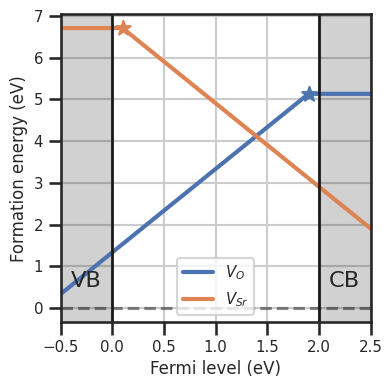

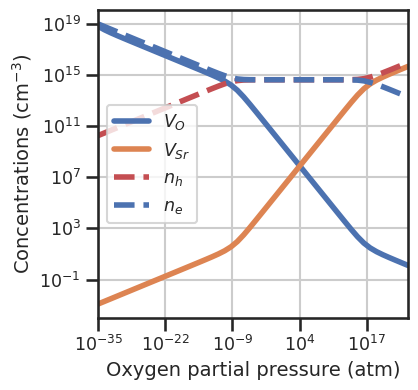

In [41]:
# set formation energies functions for Vac_O
da.set_formation_energy_functions(function=formation_energy_Vac_O,name='Vac_O')

# set formation energies functions for Vac_O
da.set_formation_energy_functions(function=formation_energy_Vac_Sr,name='Vac_Sr')

da.plot_formation_energies(chempots,temperature=1000,figsize=(4,4));
plt.show()

da.plot_brouwer_diagram(bulk_dos=bulk_dos,temperature=1000,precursors=precursors,
                        oxygen_ref=-5,pressure_range=(1e-35,1e25),
                        figsize=(4,4),fontsize=14);

## Volume-dependent concentrations

In the next example, we include the temperature-dependence of the cell volume in the defect site multiplicity, which in turn affects the defect concentrations. 

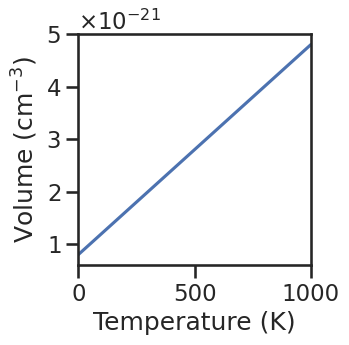

In [77]:
# T-dependence in volume in defect concentrations (made-up numbers for example)
def defect_concentrations_volume(
                entry,
                vbm=0,
                chemical_potentials=None,
                temperature=0,
                fermi_level=0,
                per_unit_volume=True,
                eform_kwargs={},
                **kwargs):
        
        # include formation energy kwargs
        conc = entry._default_defect_concentration(
                                                   vbm=vbm,
                                                   chemical_potentials=chemical_potentials,
                                                   temperature=temperature,
                                                   fermi_level=fermi_level,
                                                   per_unit_volume=per_unit_volume,
                                                   eform_kwargs=eform_kwargs)
        if per_unit_volume:
            n_corr = (1 + 1/200*temperature)
            return conc * n_corr
        else:
            return conc
        
def V(T):
    return bulk_volume*(1+1/200*T)*1e-24

plt.figure(figsize=(3,3))
plt.plot(temperatures,[V(T) for T in temperatures]) 
plt.xlim(0,1000)
plt.xlabel('Temperature (K)')
plt.ylabel('Volume (cm$^{-3}$)')
plt.ticklabel_format(axis='y',style='sci',scilimits=[0,1],useMathText=True)

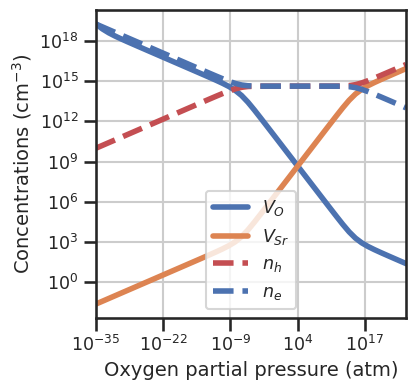

In [ ]:
# set for all entries
da.set_defect_concentration_functions(function=defect_concentrations_volume)

da.plot_brouwer_diagram(bulk_dos=bulk_dos,temperature=1000,precursors=precursors,
                        oxygen_ref=-5,pressure_range=(1e-35,1e25),
                        figsize=(4,4),fontsize=14);